 Import Libary

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Embedding

# **Load and Preprocessing**

In [ ]:
#load dataset
vocab_size = 10000
max_len = 200

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

#pad sequences
x_train = sequence.pad_sequences(x_train, maxlen=max_len)
x_test = sequence.pad_sequences(x_test, maxlen=max_len)


**Bulid Model**

**A)Simple RNN Model**

In [ ]:
def build_rnn():
  model = Sequential()
  model.add(Embedding(vocab_size, 128, input_length=max_len))
  model.add(SimpleRNN(64))
  model.add(Dense(1, activation='sigmoid'))

  model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
  return model

**B)LSTM Model**

In [ ]:
def build_lstm():
  model = Sequential()
  model.add(Embedding(vocab_size, 128, input_length=max_len))
  model.add(LSTM(64))
  model.add(Dense(1, activation='sigmoid'))

  model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
  return model

**C)GRU Model**

In [ ]:
def build_gru():
  model = Sequential()
  model.add(Embedding(vocab_size, 128, input_length=max_len))
  model.add(GRU(64))
  model.add(Dense(1, activation='sigmoid'))
  model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
  return model


**Train Model**

In [ ]:
epochs = 5
batch_size = 64

# Train RNN
rnn_model = build_rnn()
history_rnn = rnn_model.fit(x_train, y_train, epochs=epochs,
                            batch_size=batch_size, validation_split=0.2)

# Train LSTM
lstm_model = build_lstm()
history_lstm = lstm_model.fit(x_train, y_train, epochs=epochs,
                              batch_size=batch_size, validation_split=0.2)

# Train GRU
gru_model = build_gru()
history_gru = gru_model.fit(x_train, y_train, epochs=epochs,
                            batch_size=batch_size, validation_split=0.2)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 32s 95ms/step - accuracy: 0.6708 - loss: 0.5815 - val_accuracy: 0.6422 - val_loss: 0.6140
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 94ms/step - accuracy: 0.8027 - loss: 0.4401 - val_accuracy: 0.7048 - val_loss: 0.5636
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 96ms/step - accuracy: 0.9337 - loss: 0.1791 - val_accuracy: 0.7934 - val_loss: 0.5083
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 100ms/step - accuracy: 0.9927 - loss: 0.0324 - val_accuracy: 0.7926 - val_loss: 0.6216
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 96ms/step - accuracy: 0.9997 - loss: 0.0058 - val_accuracy: 0.7986 - val_loss: 0.6860
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 90s 281ms/step - accuracy: 0.7685 - loss: 0.4734 - val_accuracy: 0.8388 - val_loss: 0.3947
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 150s 308ms/step - accuracy: 0.8907 - loss: 0.2716 - val_accuracy: 0.8382 - val_loss: 0.3582
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 132s 277ms/step - accuracy: 0.9295 - loss: 0.1904 - val_accuracy

**Plot Learning Curves**

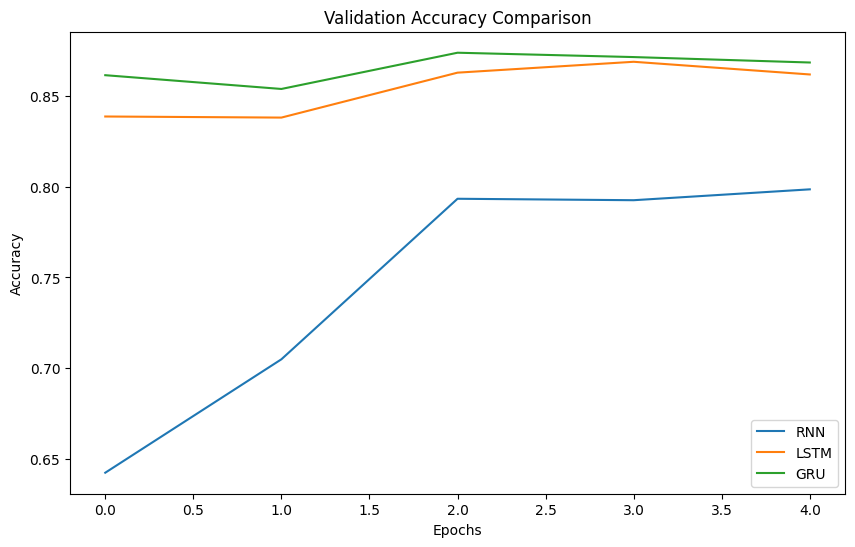

In [ ]:
def plot_history(history, label):
    plt.plot(history.history['val_accuracy'], label=label)

plt.figure(figsize=(10,6))
plot_history(history_rnn, "RNN")
plot_history(history_lstm, "LSTM")
plot_history(history_gru, "GRU")

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

**Evaluate Models**

In [ ]:
rnn_acc = rnn_model.evaluate(x_test, y_test)[1]
lstm_acc = lstm_model.evaluate(x_test, y_test)[1]
gru_acc = gru_model.evaluate(x_test, y_test)[1]

print("RNN Accuracy:", rnn_acc)
print("LSTM Accuracy:", lstm_acc)
print("GRU Accuracy:", gru_acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.7968 - loss: 0.6618
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step - accuracy: 0.8562 - loss: 0.4686
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - accuracy: 0.8547 - loss: 0.4706
RNN Accuracy: 0.7968000173568726
LSTM Accuracy: 0.8562399744987488
GRU Accuracy: 0.8546800017356873
